# 前言

在人工智能发展的最新浪潮中，大语言模型(Large Language Model，LLM)，以下简称为大模型，已成为通用智能迈向实用化与产业化的关键基石。随着Transformer架构的成熟、算力资源的快速提升以及数据训练范式的不断演进，LLM的应用早已突破传统的问答与对话任务，深入拓展到复杂任务执行、流程控制、工具调用与自主决策等高阶能力的实现之中。

在这一技术背景与需求趋势的交汇点上，智能体系统应运而生。它将LLM的理解与生成能力延展为“感知−认知−执行”一体化的任务执行框架，代表了当前人工智能系统进化的核心方向和未来发展范式。

本书旨在全面系统地讲解如何基于LLM构建智能体系统，聚焦从理论原理到工程实战的全链路技术栈。本书共分13章，涵盖LLM技术基础、Agent核心模块、LangChain框架、LangGraph框架、检索增强生成机制(RAG)、上下文协议(MCP)、多Agent通信（A2A协议）​、扣子低代码平台等关键模块，各章内容概要介绍如下：

第1章从技术演进的视角出发，介绍从专家系统到模型的发展脉络，并剖析智能体系统中的“感知−认知−执行”链条。

第2章详细拆解智能体的核心模块构成与生命周期管理机制，深入解析感知模块、推理规划模块、行动执行模块和记忆系统的协同工作原理。

第3章则聚焦LLM的服务部署与调用方式，详述SaaS与本地模型的部署流程、微调机制、LoRA注入与推理优化策略，为模型落地提供完整技术支持。

第4章介绍LangChain核心组件（LLM接口、Chains、Tools集成、Memory管理）及工具集成、Agent运行机制，涵盖链式逻辑、自定义提示词和动态规划。

第5章聚焦LangGraph编排与任务流管理，探讨其核心概念、与LangChain互补关系、工程化实战案例及与协议层衔接，助力复杂任务处理。

第6章阐述RAG机制原理、文档预处理与向量化，以及基于LangChain的RAG实现，提升智能体检索与生成能力，优化信息处理效率。

第7章系统阐述MCP(Model Context Protocol)协议，提出模型上下文段的结构化表示方法，引入系统提示、工具段、记忆段等组件，实现上下文语义标注、路由控制与动态合并，为多轮对话与任务连续性提供基础支撑。

第8、9章以实践为导向，讲解如何构建具备记忆管理与工具调用能力的单智能体系统，并进一步扩展为支持任务拆分、状态同步、消息调度的多Agent系统。

第10章介绍A2A(Agent-to-Agent)通信协议，定义Agent之间的语义协商语言与消息格式，支持请求−响应、广播−订阅、协商−竞争等多种调度模式，为多智能体系统的信息流转与行为协同提供语义基础。

第11章面向低代码场景，介绍如何利用扣子平台以可视化流程图与自然语言方式快速搭建可用的智能体应用，显著降低Agent系统的开发门槛。

第12、13章结合系统部署、安全加固、性能优化、并发处理与用户交互测试等实际工程问题，展示了一个可部署、可维护、可扩展的智能体系统从“技术原型”走向“产品落地”的完整工程闭环。同时，结合Qwen 3.0与DeepSeek-V1等主流开源模型，深入解析如何进行模型接入、RAG融合、多Agent协作与应用上线，形成一套兼顾工程可行性与产业实战性的开发路径。

本书内容深入浅出、结构严谨、案例翔实，适合希望入门LLM应用开发的初学者、探索Agent开发的工程实践者、构建企业AI平台的技术负责人，也适合作为AI教学或智能体开发团队的技术培训参考书。期待本书能够帮助读者构建一个完整的智能体系统知识体系，掌握大模型落地与Agent应用开发的关键能力，在新时代的AI浪潮中勇立潮头、实现突破。   

                                                                                                            著者
                                                                                                            2025年7月


# 第1章　大模型与智能体技术基础
## 1.1 智能体发展的技术背景
智能体的兴起源于对人工智能从被动响应向主动执行的持续探索，其演化历程伴随着知识系统、规则引擎、深度学习与大模型的阶段性突破。
### 1.1.1 从专家系统到语言模型
专家系统是人工智能早期的重要研究方向，其核心思想是模拟人类专家的知识和推理过程，通过规则库与推理引擎实现对问题的判断、分析与决策，其结构通常包括知识库、推理机、解释器与用户接口等关键组件。

#### 1.专家系统的基本原理
知识库承载了专家所具备的专业知识，通常以如果……那么形式的规则进行编码，规则由知识工程师从实际专家那里收集、整理并维护。

推理机负责在知识库的基础上执行推理操作，常见的方法包括正向链推理与逆向链推理。前者从已知事实出发，逐步推导出结论，后者则从待验证结论出发，回溯推导是否存在支持该结论的规则链。

典型的专家系统的核心模块与信息交互结构如图1-1所示，知识获取模块由知识工程师将领域专家的经验转换为机器可解析的形式，并存入知识库中。形式化的表示通常为规则对或语义网络结构。解释器负责将推理过程中的逻辑路径、结果来源与理由反馈至人机交互界面，提供“why”和“how”的信息，从而增强系统的可解释性与信任度
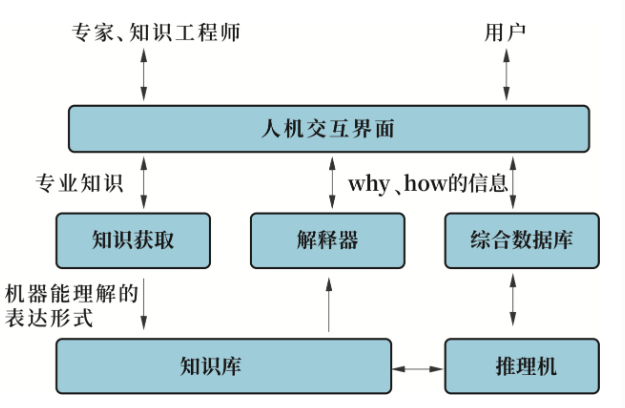

图1-1　专家系统的核心模块与信息交互结构图

综合数据库存储的是运行时数据、事实与用户输入等动态信息。推理机以该数据库为工作记忆，结合知识库中的规则集进行模式匹配、条件验证与推理链构造，从而输出结论或建议。人机交互界面是系统输入与输出的关键桥梁，既接收用户问题，也展示系统推理过程，保障系统的透明性与实用性。

专家系统具备较强的可解释性，输出结论时通常会给出推理路径与依据，适用于结构化明确、规则稳定的封闭领域。然而，其缺点也同样明显，主要包括知识获取困难、规则维护成本高、在面对模糊或开放问题时表现欠佳，缺乏通用性与适应性，尤其在语言理解、视觉感知等复杂任务中难以胜任。

#### 2.统计学习与语言建模的兴起

为解决专家系统的局限，人工智能研究逐步转向数据驱动范式，基于统计学习的方法逐渐取代了符号规则体系。在自然语言处理领域，语言模型成为核心方法之一。最早的语言模型基于n元文法，依赖词频统计构建词序列条件概率分布，尽管可以对短文本进行建模，但在处理长距离依赖与多义歧义问题时效果有限。

随着机器学习的快速发展，神经网络语言模型应运而生。通过引入嵌入向量、隐藏状态与非线性映射函数，模型能够捕捉词语之间的语义关联性。特别是循环神经网络与长短期记忆结构的引入，显著提升了语言模型对上下文的记忆能力，为语言生成、机器翻译、情感分析等任务提供了更强的建模能力。

#### 3.Transformer模型与语言智能体的奠基

标准Transformer编码器结构如图1-2所示，其核心由多头注意力机制与前馈网络组成。输入经过嵌入层后与位置编码相加，形成具备顺序感知能力的表示向量，再通过多头注意力模块进行全局依赖建模。各注意头并行计算不同语义维度下的相关性，结果通过线性投影融合，并与残差连接与层归一化组合形成稳定的特征通路。

接下来，数据经过逐位置独立的前馈网络完成非线性变换，进一步提升表示能力。最终，经过线性变换与归一化后，通过Softmax生成预测概率。整个结构可重复堆叠，形成深层语义建模能力，是现代语言智能体生成能力与推理能力的基础构件。

基于Transformer结构构建的大规模预训练模型，如BERT、GPT、T5等，不仅具备强大的文本生成与理解能力，还表现出一定的推理、归纳与任务迁移能力。随着模型规模从亿级参数扩展至百亿、千亿规模，语言模型已不仅仅是语言处理工具，而逐渐具备了类通用智能的能力，可以通过Prompt（提示词）引导完成摘要、编程、检索、问答、规划等多种任务。

三种基于Transformer架构的变体模型如图1-3所示。标准Transformer包含编码器与解码器两个子模块。编码器利用双向注意力处理输入，解码器通过掩码多头注意力机制防止未来信息泄露，用于序列到序列的建模。GPT采用解码器结构的简化版本，仅保留单向掩码注意力层，支持自回归文本生成，是典型的生成式预训练模型。BERT则完全基于编码器堆叠，通过双向注意力捕捉上下文信息，用于构建深层语义表示，广泛应用于分类、问答与抽取等理解任务。这三种结构定义了预训练语言模型的基本范式，是现代语言智能体系统任务建模与能力构建的理论基础。

这类语言模型逐步承担起语言智能体的角色，能够在开放环境中接收自然语言指令，理解用户意图，并通过语言生成方式完成复杂任务的决策与执行，展现出超越传统专家系统的灵活性与适应性。

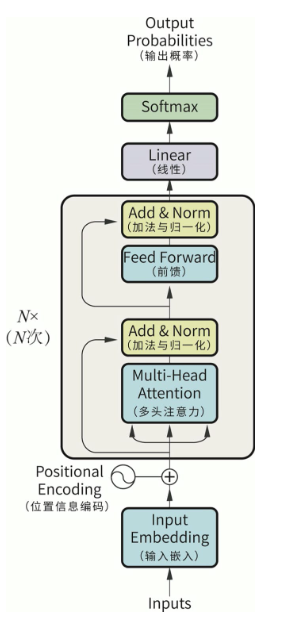

图1-2　Transformer编码器结构及其在语言建模中的计算流程

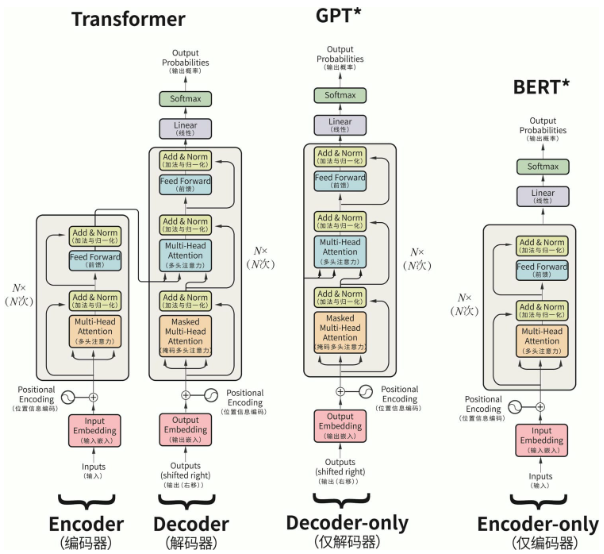

图1-3　Transformer、GPT与BERT结构对比及其模型架构差异

#### 4.范式转移与智能体系统的演化

从专家系统到语言模型的发展过程，实质上是人工智能从符号主义向连接主义，从人工规则向统计学习的根本转变。专家系统强调形式逻辑与可解释性，而现代语言模型则依赖大规模数据与非线性表示，具有更强的泛化能力与任务适应性。

这种范式转移催生了以语言模型为核心的智能体系统。新一代智能体不再依赖预定义的规则集，而是通过上下文建模、Prompt设计、外部工具调用与反馈机制实现任务执行，其结构更加开放，能力更加强大，可适应多领域、多任务的复杂交互场景。

综上所述，从专家系统到语言模型的发展历程，展现了人工智能技术体系的重大跃迁，为构建具备认知、推理与行动能力的智能体系统奠定了理论基础与技术条件，预示着通用人工智能时代的发展方向。

### 1.1.2 感知−认知−执行

感知−认知−执行(Perception-Cognition-Action)模型是构建智能体系统不可或缺的基础结构，在语言智能体架构中，该模型被具体化为语言理解、推理规划与工具调用3个关键能力模块，三者通过上下文结构与任务接口紧密协同，实现智能体从被动应答到主动决策的能力跃升。该机制不仅适用于单一Agent的任务流程，也为多智能体系统中的角色划分与协作设计提供了可扩展的结构模板。

#### 1.感知−认知−执行的基本框架

感知−认知−执行是智能体系统中核心的运行框架，其本质是模拟人类或自然智能体完成信息获取、任务决策与行动反馈的全过程，是支撑智能体自主行为与任务完成的基本逻辑链条，如图1-4所示。在人工智能领域，尤其是在大模型驱动的智能体系统中，这一结构被抽象为多层协同的任务处理体系，每个阶段对应不同类型的计算组件与信息流转机制。

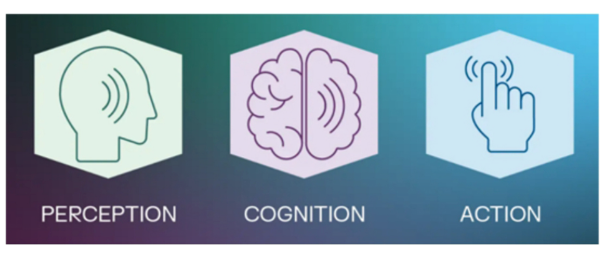

图1-4　感知−认知−执行框架

感知阶段主要负责对外部环境或用户输入进行理解与表征，认知阶段则在理解的基础上进行逻辑推理、任务规划与策略生成，执行阶段根据认知结果完成具体动作，如调用工具、访问数据库或与用户交互。三者之间具有明显的阶段性，但又通过共享上下文与中间状态保持紧密的动态耦合。

#### 2.感知阶段：信息的获取与语言解析

传统系统中，感知通常是指对物理世界的传感器数据进行采集与初步处理，如图像识别、语音转录或温度检测等。而在语言模型驱动的智能体中，感知的主要内容转换为对自然语言输入的理解与语义抽取，即将非结构化的语言表达转换为结构化的意图表示或问题形式。

这一阶段主要包括：
(1)对输入内容的语言解析能力，如句法分析、关键词提取、实体识别。
(2)对用户意图的语义建模能力，如判断请求类型、识别操作对象。
(3)对上下文历史的融合能力，实现多轮对话的上下文连贯理解。

大模型凭借其强大的文本表示能力，能够在这一阶段完成对复杂指令、多语言文本及模糊表达的深度理解，是构建任务驱动型Agent的前提条件。

#### 3.认知阶段：推理规划与行为决策

认知阶段是整个智能体系统的核心部分，涉及信息整合、逻辑推理、策略选择与任务规划等一系列认知计算过程。在这一阶段，智能体不仅要基于当前输入作出判断，还要综合历史信息、任务目标、系统状态以及外部知识进行多层次的分析与抽象。

该阶段可进一步细化为：
(1)意图识别与任务分类：确定请求类型，是查询、生成、控制还是操作。
(2)任务分解与规划：将复杂任务划分为多个子步骤，并确定执行顺序。
(3)工具选择与参数设计：根据任务目标选择合适的工具链并构造输入参数。
(4)回退与错误预判：识别潜在失败路径，构造容错与中断恢复机制。

现代大模型如通义千问Qwen 3.0、GPT-4等具备一定的链式思维与上下文推理能力，在合理设计Prompt与上下文结构的基础上，可以支持有限复杂度的规划与决策操作，是认知阶段能力实现的技术核心。


#### 4.执行阶段：动作调度与工具调用

执行阶段是认知结果的具体实现，承担任务的“最后一公里”落地工作。在传统系统中，执行通常通过调用函数、控制接口或机械部件实现，而在语言智能体中，执行往往表现为工具调用、API接口访问、数据库查询、函数执行等可编程行为。

关键构成包括：
(1)动作调度模块：根据认知输出确定需要调用的工具及其执行顺序。
(2)工具集成接口：将各类工具封装为可调用模块，并规范输入输出格式。
(3)调用反馈管理：处理工具返回结果，包括成功、失败或部分结果处理。
(4)环境状态更新：根据执行结果更新系统状态或用户上下文。

执行阶段不仅需要模型具备语言生成能力，还需依赖工程机制支持外部接口连通，因此通常需要结合LangChain、Function Calling或低代码平台进行落地实现。

#### 5.结构闭环与多轮协同

感知−认知−执行三阶段虽然在逻辑上清晰分离，但在智能体实际运行中常常呈现感知−认知−执行−再感知的闭环结构，即执行结果可能作为新一轮感知输入进入下一轮任务流程。这种循环结构使得智能体具备动态适应与自我修正能力，能够在不确定性环境下持续调整任务策略，提升整体智能表现。

此外，在多轮对话、多步骤任务执行、多Agent协作等场景中，感知−认知−执行链条会跨越多个模块并行展开，此时对上下文状态管理、任务标识追踪与信息流协调提出更高要求，只有构建稳定、统一的上下文传输协议与工具接口标准，才能支撑复杂系统中智能体的协同运行。

### 1.1.3 智能体的系统级结构模型

智能体的系统级结构模型是构建可执行、可扩展、可维护智能系统的基础框架，其核心在于模块化设计、上下文驱动协同与能力层级分布，通过感知、认知、执行、记忆与接口五大模块的有机协作，实现了从自然语言理解到任务完成的完整流程控制。该结构不仅适用于单体Agent的任务系统，也为多智能体协同、异构模型集成与平台级智能系统提供了工程化实施基础。

#### 1.智能体的系统化建模需求

随着大模型的广泛应用与任务复杂度的持续提升，单纯依赖模型调用完成问答或内容生成已难以满足真实场景中的多任务、多步骤、高稳定性需求。语言智能体作为新一代人工智能系统的核心形态，要求在模型能力的基础上构建具备结构化、可控性与模块协同能力的系统框架。因此，构建一套系统级的智能体结构模型，成为智能体工程化部署与多场景落地的前提条件。

系统级智能体模型不仅仅是语言模型的调用封装，更是感知理解、任务规划、行为执行与状态管理等模块的有机协作，是一个面向全流程、多层次的信息处理与响应体系。其构建需要在架构层、组件层与通信层等维度进行系统性设计，确保智能体具备模块独立性、调用通用性与状态可持续性。

#### 2.智能体的核心组成模块

典型的系统级智能体结构通常包括五大核心模块：感知模块、认知模块、执行模块、记忆模块与接口模块，每个模块各司其职，协同工作，构成完整的智能处理链路。

(1)感知模块：负责接收用户输入或外部环境状态，完成自然语言解析、实体识别、意图抽取等任务，是连接输入源与内部认知机制的桥梁。
(2)认知模块：承担主要的信息加工与决策任务，包括问题理解、任务分类、流程规划、工具选择等，是智能体的推理中心。
(3)执行模块：将认知阶段的决策结果转换为具体动作，常表现为工具函数的调用、API接口访问或外部系统控制，是完成实际任务的手脚系统。
(4)记忆模块：存储智能体运行过程中的短期与长期信息，包括用户历史、中间状态、上下文摘要等，是支持多轮交互与状态保持的记忆系统。
(5)接口模块：实现与外部平台、用户界面、数据库及其他智能体的通信桥接，确保系统可嵌入多种运行环境，是智能体感知世界的通道。

一种典型的语言智能体的运行架构如图1-5所示，其核心由Agent模块负责任务解析与行为决策，接收用户输入后，结合系统状态，通过内嵌的感知、推理与执行机制进行处理。Agent可访问数据库查询结构化信息，调用本地文件读取非结构化数据，或接入多模态传感器实现环境感知，通过上下文建模与Prompt编排完成推理规划。

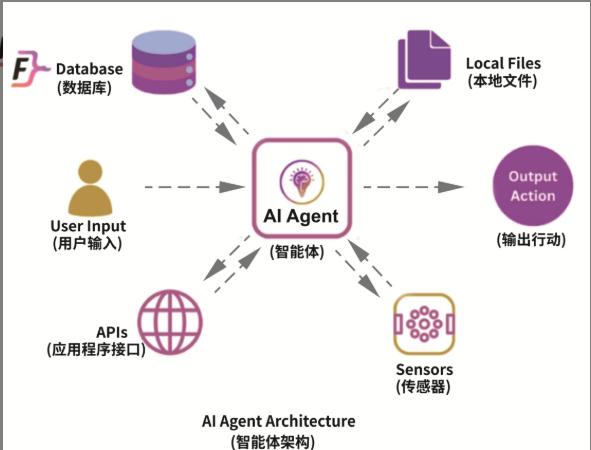

图1-5　AI智能体系统的功能构成与外部接口架构

执行层通过API调用外部服务或控制物理执行器完成任务响应，输出结果可为文本、图像、动作指令等。整个系统支持多通道双向数据流，具备环境适应、自主规划与工具协同能力，是构建复杂任务型AI Agent的基础运行框架。

以上模块通常围绕一个共享的上下文管理系统展开协同，确保信息在模块之间高效流动并被准确调用，是支撑智能体系统稳定运行与可扩展性的基础。

#### 3.模块间的信息流动与协同方式

在系统运行过程中，各模块之间的信息交互基于上下文对象(Context Object)进行统一管理，该上下文结构记录当前任务的输入、用户状态、历史调用记录、中间结果等，是系统级协同的核心信息载体。具体而言：
(1)感知模块将解析后的结构化输入写入上下文。
(2)认知模块从上下文读取用户意图与历史状态，生成行动指令。
(3)执行模块根据指令调用工具，将结果写入上下文。
(4)记忆模块定期将上下文内容进行摘要或分层存储，供后续调用。
(5)接口模块负责上下文与外部环境之间的数据交换与同步。

这种基于上下文驱动的模块协作模式，有利于智能体系统的解耦扩展与过程追踪，也是多智能体系统中信息同步与状态共享的重要支撑机制。

#### 4.智能体系统的分层架构模式

为实现模块功能的清晰划分与系统部署的灵活扩展，智能体系统通常采用分层架构设计，可划分为以下3个层级：

(1)基础模型层：负责底层语言能力的提供，包含大模型的推理服务、Embedding服务、多模态理解模型等。

(2)智能体能力层：以Agent为单位构建任务执行体，包含感知、认知、执行与记忆模块，负责接收任务请求并完成推理与操作流程。

(3)应用与接口层：提供前端交互、系统调用、API封装与多系统协同能力，实现与用户界面或其他平台的集成部署。

这种分层结构使得系统具备良好的模块解耦性与开发可维护性，模型层可以独立升级，能力层支持横向扩展，接口层则可根据场景灵活调整，提高系统的整体稳定性与部署适应性。

#### 5.智能体系统的动态演化机制

现代智能体系统不仅具备静态结构能力，还应具备自适应与演化能力，可在运行中不断学习与优化，主要体现在以下3个方面：

(1)记忆增强与状态沉淀：通过记忆模块对用户行为与交互历史进行建模，实现长期状态的积累与复用。

(2)行为反馈与策略更新：基于任务执行结果自动调整Prompt、工具调用顺序或调用条件，形成自我优化闭环。

(3)模块热插拔与功能迁移：支持动态替换、加载或禁用某些功能模块，使系统具备弹性与可配置能力。

这些演化机制使得智能体不再是静态流程的简单执行器，而逐步演化为具备适应能力的自主系统，具备跨任务、跨场景的泛化应用潜力。

## 1.2 大模型的基本架构

大模型作为智能体系统的认知核心，其架构设计直接决定了语言理解与生成的能力边界。Transformer作为当前主流的大模型基础结构，凭借其自注意力机制与多层堆叠架构，在长距离依赖建模与并行计算效率上取得突破性进展。本节将系统介绍大模型的核心构成与关键机制，重点剖析Transformer的结构原理、编码和解码过程、注意力机制的计算方式以及位置编码的语义作用，为后续智能体系统中的模型能力调度与上下文管理打下结构性认知基础。


### 1.2.1 Transformer结构剖析

Transformer结构作为现代大模型的基础架构，通过自注意力机制、多头注意力、前馈网络、残差连接与位置编码等模块，构建了具备强大上下文建模能力与并行计算优势的神经网络结构。其灵活的编码器−解码器设计不仅适用于语言理解任务，也广泛应用于语言生成、对话系统、多模态交互等场景，是语言智能体系统实现的基础支撑。理解Transformer的结构逻辑是把握大模型行为与智能体能力边界的关键前提。

#### 1.Transformer模型的提出背景

Transformer结构是当前大模型的核心架构，自2017年被提出以来，已成为自然语言处理领域最重要的基础技术之一。其设计初衷是为了解决传统循环神经网络在序列建模中存在的长期依赖问题与训练效率瓶颈。相比于RNN与LSTM，Transformer完全抛弃了时间步迭代结构，采用全并行的自注意力机制，使得模型在序列建模中兼顾了建模能力与计算效率，成为后续BERT、GPT、T5等主流模型的基础结构。

Transformer的核心在于其堆叠式的编码器−解码器架构与全局注意力机制，能够实现对输入序列中任意位置信息的建模，是支持语言理解与生成任务的关键机制，其架构的模块化、层级化特点也极大地增强了系统的可扩展性，便于与其他智能体组件协同构建复杂任务流程。

#### 2.模型整体结构组成

标准的Transformer架构由编码器(Encoder)与解码器(Decoder)两部分构成，分别用于处理输入信息与生成输出结果，整个模型结构呈现对称堆叠的层级设计，每一层均由多个子模块组成，具有高度可复用性与并行计算能力。

(1)编码器部分主要负责接收输入序列，通过多层自注意力机制与前馈网络提取上下文表示，输出每个位置对应的上下文特征。

(2)解码器部分则以编码器输出为条件，通过掩码自注意力与交叉注意力机制生成目标序列，是支持序列生成与翻译等任务的关键。




